# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Método de la tangente de Ziegler-Nichols

## Heater 1

K (ganancia estática): 0.53
Punto de inflexión: 50.08 s
Pendiente máxima: 0.05 °C/s
Cruce con techo: 201.17 s
theta (tiempo muerto): 9.03 s
tau (constante de tiempo): 182.13 s


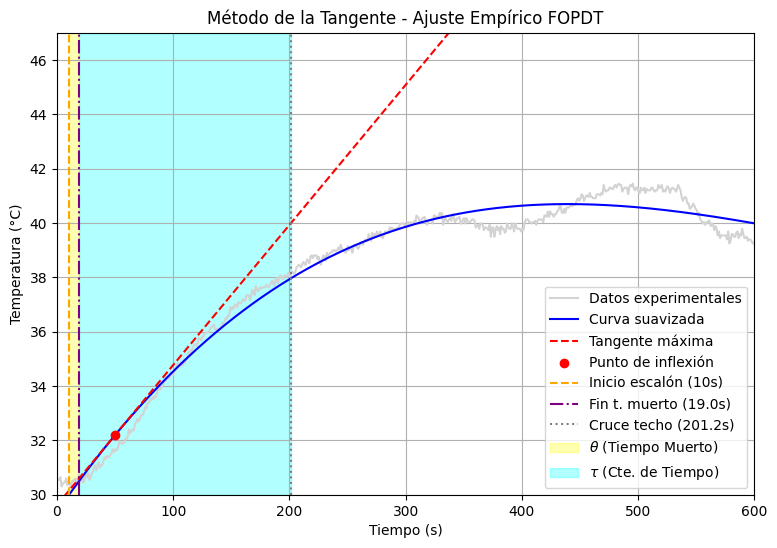

In [2]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("dataQ1_on.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp1 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Derivada sobre curva suavizada (Limitada entre 50 y 300 s)
# -----------------------------
# Calculamos la pendiente usando la derivada analítica del polinomio
derivada = np.polyder(polinomio)
pendientes = derivada(t_suave)

# Obtenemos solo los índices donde el tiempo suavizado está entre 50 y 300 segundos
indices_validos = np.where((t_suave >= 50) & (t_suave <= 300))[0]

# Buscamos el índice del máximo SOLO dentro de esas pendientes válidas
indice_relativo = np.argmax(pendientes[indices_validos])

# Recuperamos el índice real para aplicarlo a nuestros vectores suavizados
indice = indices_validos[indice_relativo]

# Extraemos el tiempo, la temperatura y la pendiente en el punto de inflexión
t_inf = t_suave[indice]
y_inf = temp_suave[indice]
pendiente = pendientes[indice]

# -----------------------------
# 5. Tangente
# -----------------------------
t_linea = np.linspace(0, 600, 600)
tangente = pendiente * (t_linea - t_inf) + y_inf
# -----------------------------
# 6. Calcular theta y tau
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]

t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Tiempo absoluto donde la tangente cruza la temperatura final (techo)
t_cruce_techo = t_inf + (yf - y_inf)/pendiente

# --- CÁLCULOS EMPÍRICOS (Ajuste a la realidad física) ---
# Buscamos el primer índice donde la temperatura suavizada es mayor o igual a 30.5
indice_305 = np.where(temp_suave >= 30.5)[0][0]
t_305 = t_suave[indice_305]

# Tiempo muerto: desde que se manda el escalón hasta que llega a 30.5°C
theta = t_305 - t_escalon  

# Constante de tiempo: desde el inicio real hasta el cruce con el techo
tau = t_cruce_techo - t_305 

delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.2f}")
print(f"Punto de inflexión: {t_inf:.2f} s")
print(f"Pendiente máxima: {pendiente:.2f} °C/s")
print(f"Cruce con techo: {t_cruce_techo:.2f} s")
print(f"theta (tiempo muerto): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 7. Graficar
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada", color="blue")
plt.plot(t_linea, tangente, "--", color="red", label="Tangente máxima")

plt.scatter(t_inf, y_inf, color="red", zorder=5, label="Punto de inflexión")

# Líneas verticales marcando los parámetros empíricos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (10s)")
plt.axvline(t_305, linestyle="-.", color="purple", label=f"Fin t. muerto ({t_305:.1f}s)")
plt.axvline(t_cruce_techo, linestyle=":", color="gray", label=f"Cruce techo ({t_cruce_techo:.1f}s)")

# Sombrear las zonas para ver gráficamente theta y tau
plt.axvspan(t_escalon, t_305, color='yellow', alpha=0.3, label=r'$\theta$ (Tiempo Muerto)')
plt.axvspan(t_305, t_cruce_techo, color='cyan', alpha=0.3, label=r'$\tau$ (Cte. de Tiempo)')

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Método de la Tangente - Ajuste Empírico FOPDT")

plt.legend(loc="lower right")
plt.grid()

plt.xlim(0, 600)
plt.ylim(30.0, 47)

plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.53
$$

**Constante de tiempo:**

$$
T_s = 182.13 \; s
$$

**Tiempo muerto:**

$$
\theta = 9.03 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.53}{182.13\,s + 1}\,e^{-9.03\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

## Validación del modelo

RMSE del modelo: 0.7124249346215604


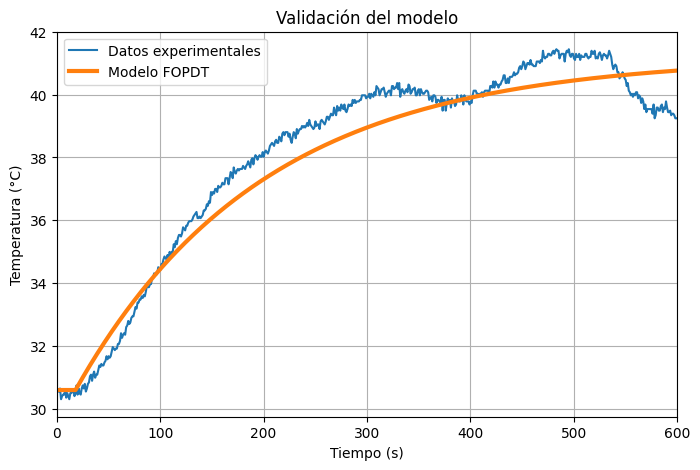

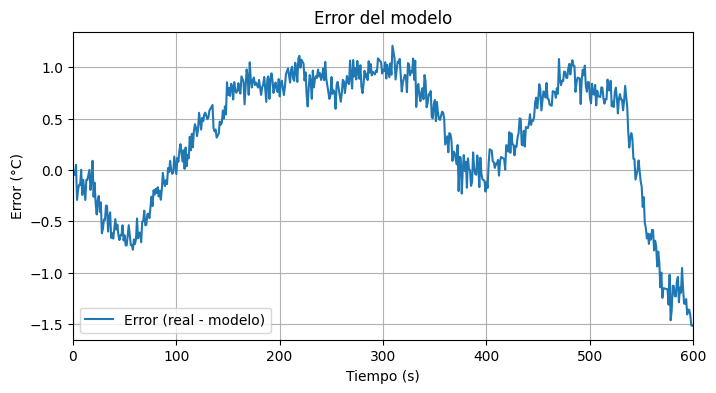

In [3]:
# parametros identificados
K = 0.53
tau = 182.13
theta = 9.03

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

# aplicar tiempo muerto
delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)
u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [4]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.8687143030766136 %


## Heater 2

K (ganancia estática): 0.77
Punto de inflexión: 50.08 s
Pendiente máxima: 0.06 °C/s
Cruce con techo: 269.51 s
theta (tiempo muerto): 10.03 s
tau (constante de tiempo): 249.48 s


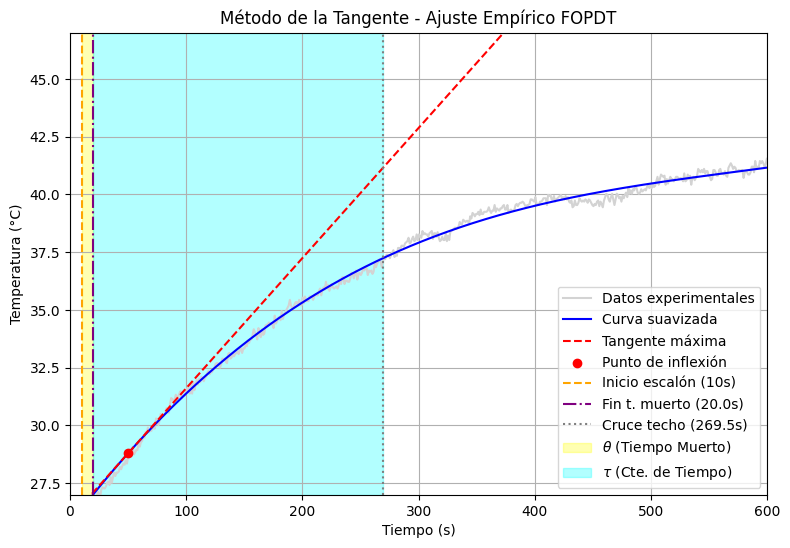

In [5]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("dataQ2_on.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp2 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Derivada sobre curva suavizada (Limitada entre 50 y 300 s)
# -----------------------------
# Calculamos la pendiente usando la derivada analítica del polinomio
derivada = np.polyder(polinomio)
pendientes = derivada(t_suave)

# Obtenemos solo los índices donde el tiempo suavizado está entre 50 y 300 segundos
indices_validos = np.where((t_suave >= 50) & (t_suave <= 300))[0]

# Buscamos el índice del máximo SOLO dentro de esas pendientes válidas
indice_relativo = np.argmax(pendientes[indices_validos])

# Recuperamos el índice real para aplicarlo a nuestros vectores suavizados
indice = indices_validos[indice_relativo]

# Extraemos el tiempo, la temperatura y la pendiente en el punto de inflexión
t_inf = t_suave[indice]
y_inf = temp_suave[indice]
pendiente = pendientes[indice]

# -----------------------------
# 5. Tangente
# -----------------------------
t_linea = np.linspace(0, 600, 600)
tangente = pendiente * (t_linea - t_inf) + y_inf
# -----------------------------
# 6. Calcular theta y tau
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]

t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Tiempo absoluto donde la tangente cruza la temperatura final (techo)
t_cruce_techo = t_inf + (yf - y_inf)/pendiente

# --- CÁLCULOS EMPÍRICOS (Ajuste a la realidad física) ---
# Buscamos el primer índice donde la temperatura suavizada es mayor o igual a 30.5
indice_305 = np.where(temp_suave >= 27)[0][0]
t_305 = t_suave[indice_305]

# Tiempo muerto: desde que se manda el escalón hasta que llega a 30.5°C
theta = t_305 - t_escalon  

# Constante de tiempo: desde el inicio real hasta el cruce con el techo
tau = t_cruce_techo - t_305 

delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.2f}")
print(f"Punto de inflexión: {t_inf:.2f} s")
print(f"Pendiente máxima: {pendiente:.2f} °C/s")
print(f"Cruce con techo: {t_cruce_techo:.2f} s")
print(f"theta (tiempo muerto): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 7. Graficar
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada", color="blue")
plt.plot(t_linea, tangente, "--", color="red", label="Tangente máxima")

plt.scatter(t_inf, y_inf, color="red", zorder=5, label="Punto de inflexión")

# Líneas verticales marcando los parámetros empíricos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (10s)")
plt.axvline(t_305, linestyle="-.", color="purple", label=f"Fin t. muerto ({t_305:.1f}s)")
plt.axvline(t_cruce_techo, linestyle=":", color="gray", label=f"Cruce techo ({t_cruce_techo:.1f}s)")

# Sombrear las zonas para ver gráficamente theta y tau
plt.axvspan(t_escalon, t_305, color='yellow', alpha=0.3, label=r'$\theta$ (Tiempo Muerto)')
plt.axvspan(t_305, t_cruce_techo, color='cyan', alpha=0.3, label=r'$\tau$ (Cte. de Tiempo)')

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Método de la Tangente - Ajuste Empírico FOPDT")

plt.legend(loc="lower right")
plt.grid()

plt.xlim(0, 600)
plt.ylim(27.0, 47)

plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.77
$$

**Constante de tiempo:**

$$
T_s = 249.48 \; s
$$

**Tiempo muerto:**

$$
\theta = 10.03 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.77}{249.48\,s + 1}\,e^{-10.03\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

## Validación del modelo

RMSE del modelo: 0.6313645236714924


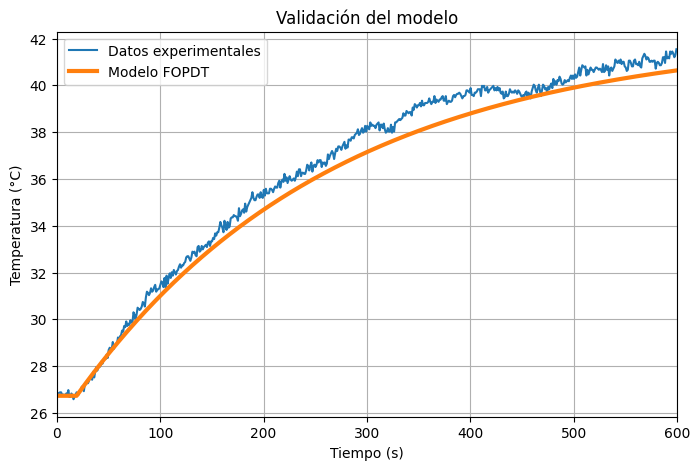

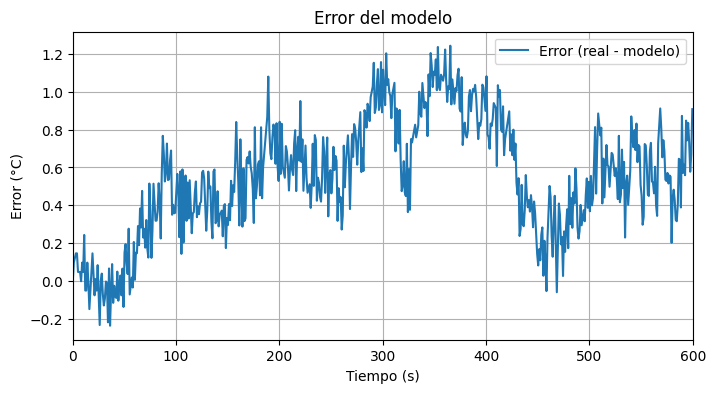

In [6]:
# parametros identificados
K = 0.77
tau = 249.48
theta = 10.03

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [7]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.732966140316226 %


# Método de dos puntos de SMITH

## Heater 1

K (ganancia estática): 0.531
Temperatura al 28.3% (y_28): 32.37 °C en t=54.09 s
Temperatura al 63.2% (y_63): 36.08 °C en t=140.23 s
theta (tiempo muerto real): 11.02 s
tau (constante de tiempo): 129.22 s


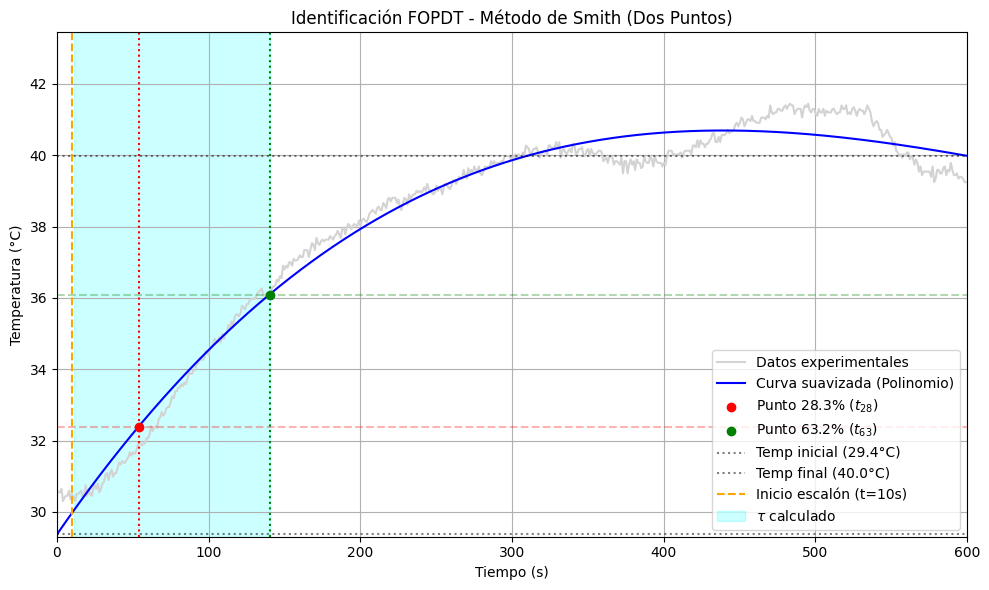

In [8]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("dataQ1_on.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp1 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado original)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Cálculos del Método de Smith (Dos puntos)
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]
delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado en %
t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Calculamos las temperaturas objetivo (28.3% y 63.2% del cambio total)
y_28 = y0 + (0.283 * delta_y)
y_63 = y0 + (0.632 * delta_y)

# Buscamos en qué índice (y por tanto, qué tiempo) se alcanzan esas temperaturas
indice_28 = np.where(temp_suave >= y_28)[0][0]
t_28 = t_suave[indice_28]

indice_63 = np.where(temp_suave >= y_63)[0][0]
t_63 = t_suave[indice_63]

# -----------------------------
# 5. Calcular Parámetros FOPDT (Fórmulas de Smith)
# -----------------------------
# Calculamos tau según la fórmula de Smith
tau = 1.5 * (t_63 - t_28)

# Calculamos el cruce con la base (tiempo muerto absoluto)
t_m_absoluto = t_63 - tau

# Restamos el tiempo del escalón para tener el tiempo muerto real
theta = t_m_absoluto

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.3f}")
print(f"Temperatura al 28.3% (y_28): {y_28:.2f} °C en t={t_28:.2f} s")
print(f"Temperatura al 63.2% (y_63): {y_63:.2f} °C en t={t_63:.2f} s")
print(f"theta (tiempo muerto real): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 6. Graficar
# -----------------------------
plt.figure(figsize=(10, 6))

# Curvas principales
plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada (Polinomio)", color="blue")

# Puntos clave de Smith
plt.scatter(t_28, y_28, color="red", zorder=5, label="Punto 28.3% ($t_{28}$)")
plt.scatter(t_63, y_63, color="green", zorder=5, label="Punto 63.2% ($t_{63}$)")

# Líneas horizontales de referencia
plt.axhline(y0, color="black", linestyle=":", alpha=0.5, label=f"Temp inicial ({y0:.1f}°C)")
plt.axhline(yf, color="black", linestyle=":", alpha=0.5, label=f"Temp final ({yf:.1f}°C)")
plt.axhline(y_28, color="red", linestyle="--", alpha=0.3)
plt.axhline(y_63, color="green", linestyle="--", alpha=0.3)

# Líneas verticales marcando los tiempos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (t=10s)")
plt.axvline(t_28, linestyle=":", color="red")
plt.axvline(t_63, linestyle=":", color="green")

# Sombrear las zonas calculadas (Opcional, para visualizar tau)
plt.axvspan(t_m_absoluto, t_m_absoluto + tau, color='cyan', alpha=0.2, label=r'$\tau$ calculado')

# Configuraciones del gráfico
plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Identificación FOPDT - Método de Smith (Dos Puntos)")
plt.legend(loc="lower right")
plt.grid(True)

# Ajuste de ejes para mejor visualización
plt.xlim(0, 600)
plt.ylim(min(temp)-1, max(temp)+2)

plt.tight_layout()
plt.show()

### Modelo del proceso identificado

A partir del método SMITH de dos puntos, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.53
$$

**Constante de tiempo:**

$$
T_s = 129.22 \; s
$$

**Tiempo muerto:**

$$
\theta = 11.02 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.53}{129.22\,s + 1}\,e^{-11.02\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

RMSE del modelo: 0.6896076341844878


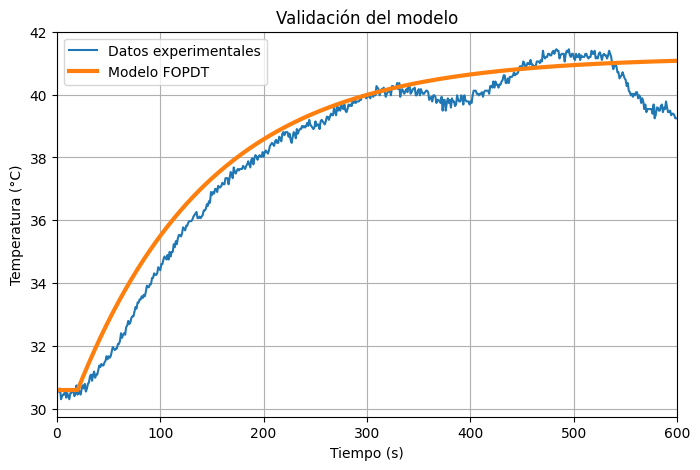

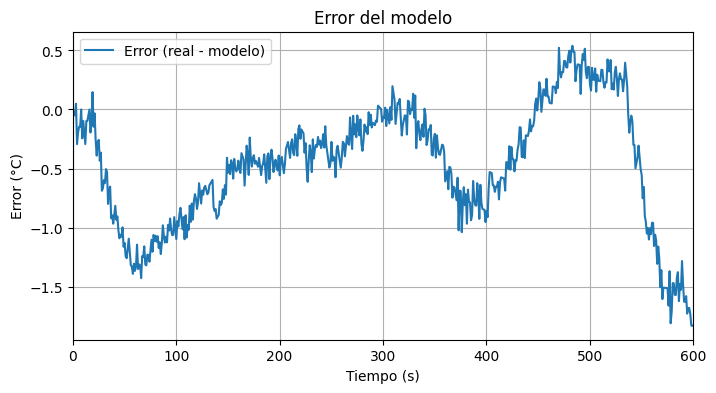

In [9]:
# parametros identificados
K = 0.53
tau = 129.22
theta = 11.02

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [10]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.8088637649886905 %


## Heater 2

K (ganancia estática): 0.772
Temperatura al 28.3% (y_28): 30.10 °C en t=74.12 s
Temperatura al 63.2% (y_63): 35.48 °C en t=205.34 s
theta (tiempo muerto real): 8.51 s
tau (constante de tiempo): 196.83 s


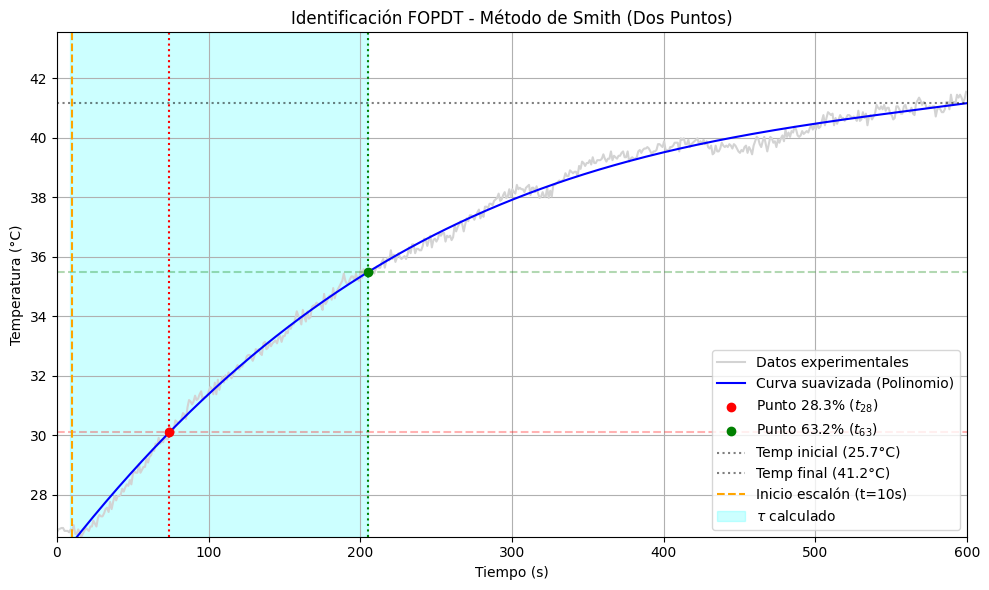

In [11]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("dataQ2_on.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp2 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado original)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Cálculos del Método de Smith (Dos puntos)
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]
delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado en %
t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Calculamos las temperaturas objetivo (28.3% y 63.2% del cambio total)
y_28 = y0 + (0.283 * delta_y)
y_63 = y0 + (0.632 * delta_y)

# Buscamos en qué índice (y por tanto, qué tiempo) se alcanzan esas temperaturas
indice_28 = np.where(temp_suave >= y_28)[0][0]
t_28 = t_suave[indice_28]

indice_63 = np.where(temp_suave >= y_63)[0][0]
t_63 = t_suave[indice_63]

# -----------------------------
# 5. Calcular Parámetros FOPDT (Fórmulas de Smith)
# -----------------------------
# Calculamos tau según la fórmula de Smith
tau = 1.5 * (t_63 - t_28)

# Calculamos el cruce con la base (tiempo muerto absoluto)
t_m_absoluto = t_63 - tau

# Restamos el tiempo del escalón para tener el tiempo muerto real
theta = t_m_absoluto

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.3f}")
print(f"Temperatura al 28.3% (y_28): {y_28:.2f} °C en t={t_28:.2f} s")
print(f"Temperatura al 63.2% (y_63): {y_63:.2f} °C en t={t_63:.2f} s")
print(f"theta (tiempo muerto real): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 6. Graficar
# -----------------------------
plt.figure(figsize=(10, 6))

# Curvas principales
plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada (Polinomio)", color="blue")

# Puntos clave de Smith
plt.scatter(t_28, y_28, color="red", zorder=5, label="Punto 28.3% ($t_{28}$)")
plt.scatter(t_63, y_63, color="green", zorder=5, label="Punto 63.2% ($t_{63}$)")

# Líneas horizontales de referencia
plt.axhline(y0, color="black", linestyle=":", alpha=0.5, label=f"Temp inicial ({y0:.1f}°C)")
plt.axhline(yf, color="black", linestyle=":", alpha=0.5, label=f"Temp final ({yf:.1f}°C)")
plt.axhline(y_28, color="red", linestyle="--", alpha=0.3)
plt.axhline(y_63, color="green", linestyle="--", alpha=0.3)

# Líneas verticales marcando los tiempos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (t=10s)")
plt.axvline(t_28, linestyle=":", color="red")
plt.axvline(t_63, linestyle=":", color="green")

# Sombrear las zonas calculadas (Opcional, para visualizar tau)
plt.axvspan(t_m_absoluto, t_m_absoluto + tau, color='cyan', alpha=0.2, label=r'$\tau$ calculado')

# Configuraciones del gráfico
plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Identificación FOPDT - Método de Smith (Dos Puntos)")
plt.legend(loc="lower right")
plt.grid(True)

# Ajuste de ejes para mejor visualización
plt.xlim(0, 600)
plt.ylim(min(temp), max(temp)+2)

plt.tight_layout()
plt.show()

### Modelo del proceso identificado

A partir del método SMITH de dos puntos, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.77
$$

**Constante de tiempo:**

$$
T_s = 196.83 \; s
$$

**Tiempo muerto:**

$$
\theta = 8.51 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.77}{196.83\,s + 1}\,e^{-8.51\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

RMSE del modelo: 0.5676572189599169


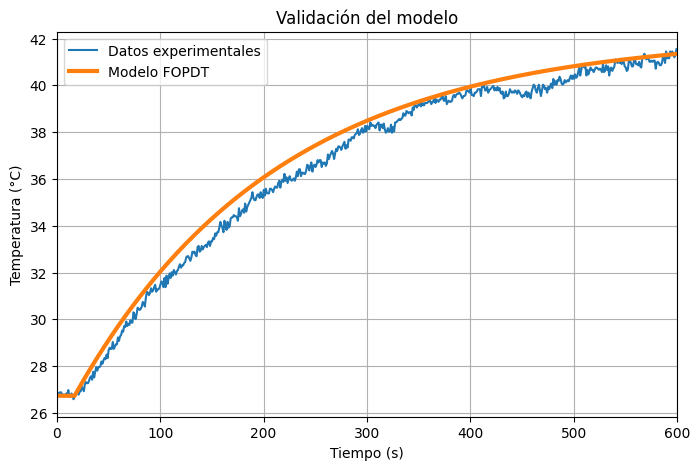

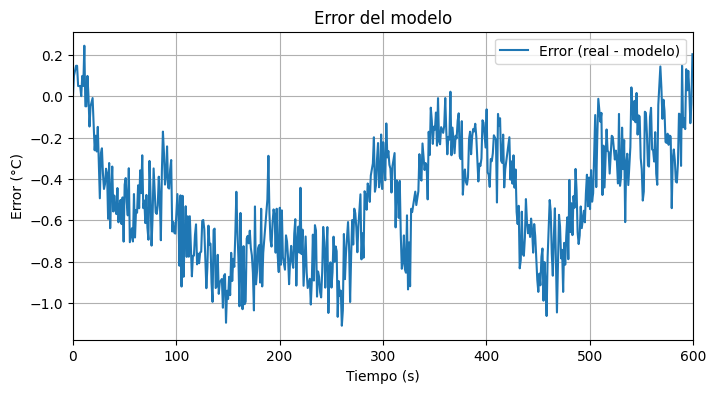

In [12]:
# parametros identificados
K = 0.77
tau = 196.83
theta = 8.51

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [13]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.5581026536667724 %


# Analisís de perturbación (Caso de prender un Heater tiempo despues y ver el comportameinto de ambos)

## Heater 1 - Tangente

K (ganancia estática): 0.93
Punto de inflexión: 50.08 s
Pendiente máxima: 0.05 °C/s
Cruce con techo: 370.23 s
theta (tiempo muerto): 5.03 s
tau (constante de tiempo): 355.20 s


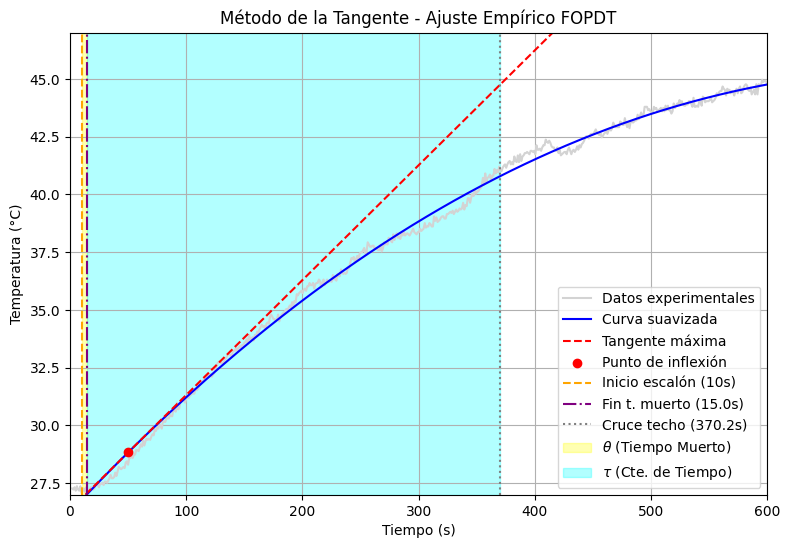

In [33]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("data.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp1 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Derivada sobre curva suavizada (Limitada entre 50 y 300 s)
# -----------------------------
# Calculamos la pendiente usando la derivada analítica del polinomio
derivada = np.polyder(polinomio)
pendientes = derivada(t_suave)

# Obtenemos solo los índices donde el tiempo suavizado está entre 50 y 300 segundos
indices_validos = np.where((t_suave >= 50) & (t_suave <= 300))[0]

# Buscamos el índice del máximo SOLO dentro de esas pendientes válidas
indice_relativo = np.argmax(pendientes[indices_validos])

# Recuperamos el índice real para aplicarlo a nuestros vectores suavizados
indice = indices_validos[indice_relativo]

# Extraemos el tiempo, la temperatura y la pendiente en el punto de inflexión
t_inf = t_suave[indice]
y_inf = temp_suave[indice]
pendiente = pendientes[indice]

# -----------------------------
# 5. Tangente
# -----------------------------
t_linea = np.linspace(0, 600, 600)
tangente = pendiente * (t_linea - t_inf) + y_inf
# -----------------------------
# 6. Calcular theta y tau
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]

t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Tiempo absoluto donde la tangente cruza la temperatura final (techo)
t_cruce_techo = t_inf + (yf - y_inf)/pendiente

# --- CÁLCULOS EMPÍRICOS (Ajuste a la realidad física) ---
# Buscamos el primer índice donde la temperatura suavizada es mayor o igual a 30.5
indice_305 = np.where(temp_suave >= 27)[0][0]
t_305 = t_suave[indice_305]

# Tiempo muerto: desde que se manda el escalón hasta que llega a 30.5°C
theta = t_305 - t_escalon  

# Constante de tiempo: desde el inicio real hasta el cruce con el techo
tau = t_cruce_techo - t_305 

delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.2f}")
print(f"Punto de inflexión: {t_inf:.2f} s")
print(f"Pendiente máxima: {pendiente:.2f} °C/s")
print(f"Cruce con techo: {t_cruce_techo:.2f} s")
print(f"theta (tiempo muerto): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 7. Graficar
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada", color="blue")
plt.plot(t_linea, tangente, "--", color="red", label="Tangente máxima")

plt.scatter(t_inf, y_inf, color="red", zorder=5, label="Punto de inflexión")

# Líneas verticales marcando los parámetros empíricos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (10s)")
plt.axvline(t_305, linestyle="-.", color="purple", label=f"Fin t. muerto ({t_305:.1f}s)")
plt.axvline(t_cruce_techo, linestyle=":", color="gray", label=f"Cruce techo ({t_cruce_techo:.1f}s)")

# Sombrear las zonas para ver gráficamente theta y tau
plt.axvspan(t_escalon, t_305, color='yellow', alpha=0.3, label=r'$\theta$ (Tiempo Muerto)')
plt.axvspan(t_305, t_cruce_techo, color='cyan', alpha=0.3, label=r'$\tau$ (Cte. de Tiempo)')

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Método de la Tangente - Ajuste Empírico FOPDT")

plt.legend(loc="lower right")
plt.grid()

plt.xlim(0, 600)
plt.ylim(27.0, 47)

plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.93
$$

**Constante de tiempo:**

$$
T_s = 355.20 \; s
$$

**Tiempo muerto:**

$$
\theta = 5.03 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.93}{355.20\,s + 1}\,e^{-5.03\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

### Validación del modelo

RMSE del modelo: 1.556272451122271


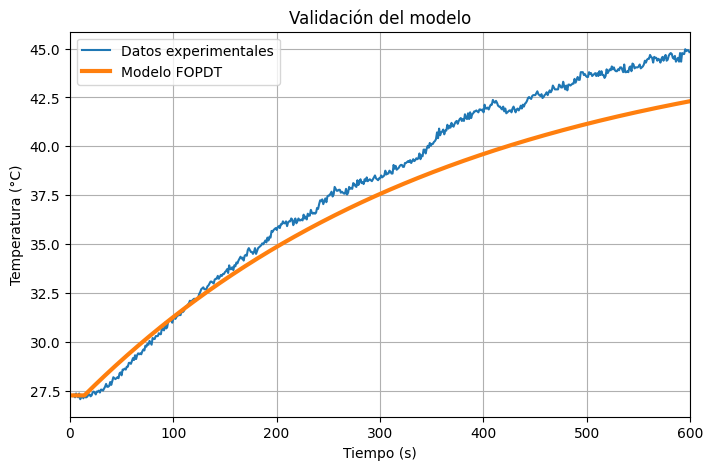

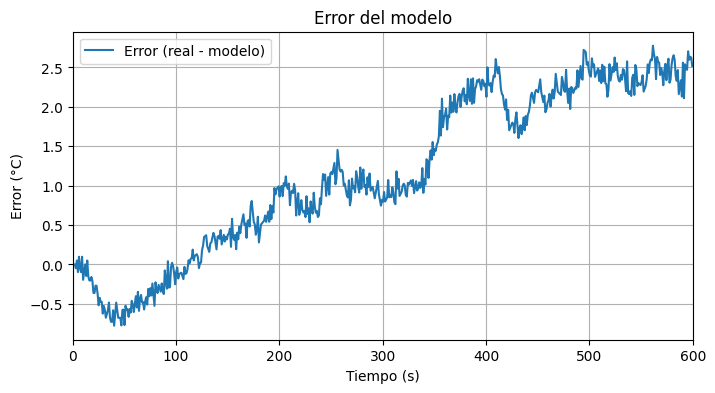

In [34]:
# parametros identificados
K = 0.93
tau = 355.20
theta = 5.03

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [35]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 4.126832406144644 %


## Heater 2 - Tangente

K (ganancia estática): 0.92
Punto de inflexión: 250.10 s
Pendiente máxima: 0.06 °C/s
Cruce con techo: 477.65 s
theta (tiempo muerto): 5.01 s
tau (constante de tiempo): 282.64 s


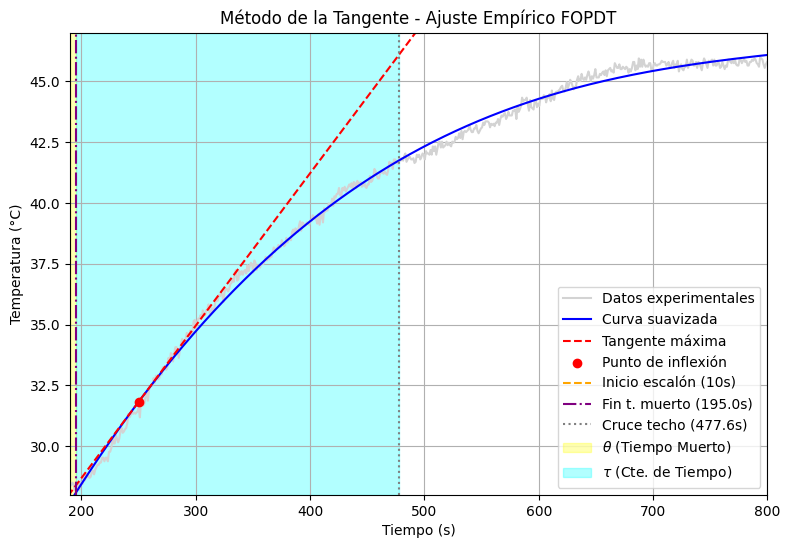

In [36]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("data.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp2 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 190) & (t <= 800)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(190, 800, 610)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Derivada sobre curva suavizada (Limitada entre 50 y 300 s)
# -----------------------------
# Calculamos la pendiente usando la derivada analítica del polinomio
derivada = np.polyder(polinomio)
pendientes = derivada(t_suave)

# Obtenemos solo los índices donde el tiempo suavizado está entre 50 y 300 segundos
indices_validos = np.where((t_suave >= 250) & (t_suave <= 400))[0]

# Buscamos el índice del máximo SOLO dentro de esas pendientes válidas
indice_relativo = np.argmax(pendientes[indices_validos])

# Recuperamos el índice real para aplicarlo a nuestros vectores suavizados
indice = indices_validos[indice_relativo]

# Extraemos el tiempo, la temperatura y la pendiente en el punto de inflexión
t_inf = t_suave[indice]
y_inf = temp_suave[indice]
pendiente = pendientes[indice]

# -----------------------------
# 5. Tangente
# -----------------------------
t_linea = np.linspace(0, 600, 600)
tangente = pendiente * (t_linea - t_inf) + y_inf
# -----------------------------
# 6. Calcular theta y tau
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]

t_escalon = 190.0  # El escalón de potencia se aplicó en el segundo 10

# Tiempo absoluto donde la tangente cruza la temperatura final (techo)
t_cruce_techo = t_inf + (yf - y_inf)/pendiente

# --- CÁLCULOS EMPÍRICOS (Ajuste a la realidad física) ---
# Buscamos el primer índice donde la temperatura suavizada es mayor o igual a 30.5
indice_305 = np.where(temp_suave >= 28)[0][0]
t_305 = t_suave[indice_305]

# Tiempo muerto: desde que se manda el escalón hasta que llega a 30.5°C
theta = t_305 - t_escalon  

# Constante de tiempo: desde el inicio real hasta el cruce con el techo
tau = t_cruce_techo - t_305 

delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.2f}")
print(f"Punto de inflexión: {t_inf:.2f} s")
print(f"Pendiente máxima: {pendiente:.2f} °C/s")
print(f"Cruce con techo: {t_cruce_techo:.2f} s")
print(f"theta (tiempo muerto): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 7. Graficar
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada", color="blue")
plt.plot(t_linea, tangente, "--", color="red", label="Tangente máxima")

plt.scatter(t_inf, y_inf, color="red", zorder=5, label="Punto de inflexión")

# Líneas verticales marcando los parámetros empíricos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (10s)")
plt.axvline(t_305, linestyle="-.", color="purple", label=f"Fin t. muerto ({t_305:.1f}s)")
plt.axvline(t_cruce_techo, linestyle=":", color="gray", label=f"Cruce techo ({t_cruce_techo:.1f}s)")

# Sombrear las zonas para ver gráficamente theta y tau
plt.axvspan(t_escalon, t_305, color='yellow', alpha=0.3, label=r'$\theta$ (Tiempo Muerto)')
plt.axvspan(t_305, t_cruce_techo, color='cyan', alpha=0.3, label=r'$\tau$ (Cte. de Tiempo)')

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Método de la Tangente - Ajuste Empírico FOPDT")

plt.legend(loc="lower right")
plt.grid()

plt.xlim(190, 800)
plt.ylim(28.0, 47)

plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.92
$$

**Constante de tiempo:**

$$
T_s = 282.64 \; s
$$

**Tiempo muerto:**

$$
\theta = 5.01 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.92}{282.64\,s + 1}\,e^{-5.01\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

### Validación del modelo

RMSE del modelo: 1.4989276543666519


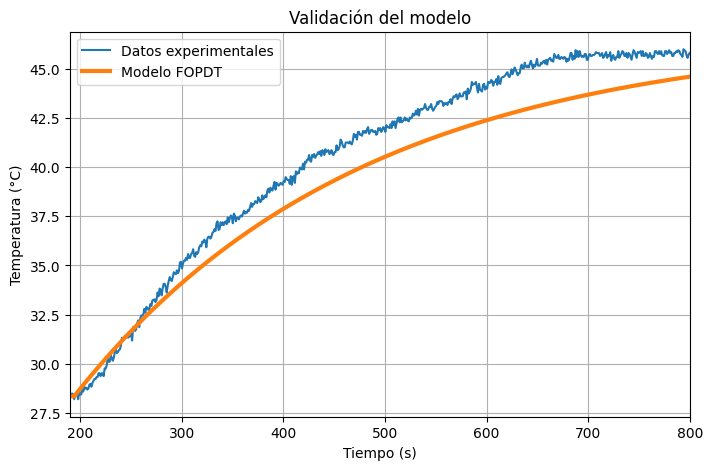

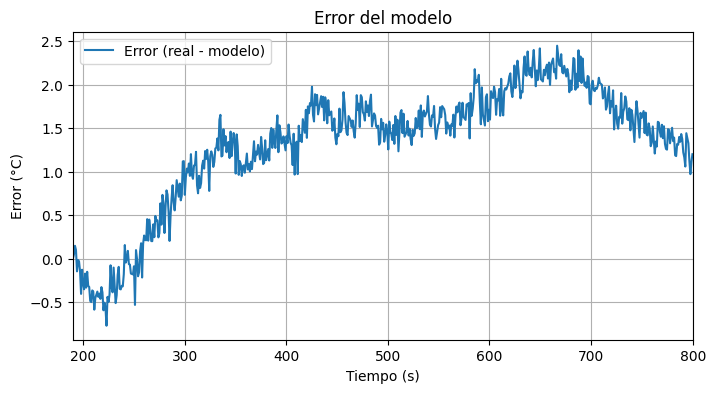

In [37]:
# parametros identificados
K = 0.92
tau = 282.64
theta = 5.01

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 190] = 20   # escalón aplicado en t = 190 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()
plt.xlim(190,800)
plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(190,800)

plt.show()

In [38]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 3.7079677206180097 %


## Heater 1 - SMITH

K (ganancia estática): 0.926
Temperatura al 28.3% (y_28): 31.48 °C en t=106.18 s
Temperatura al 63.2% (y_63): 37.94 °C en t=272.45 s
theta (tiempo muerto real): 23.04 s
tau (constante de tiempo): 249.42 s


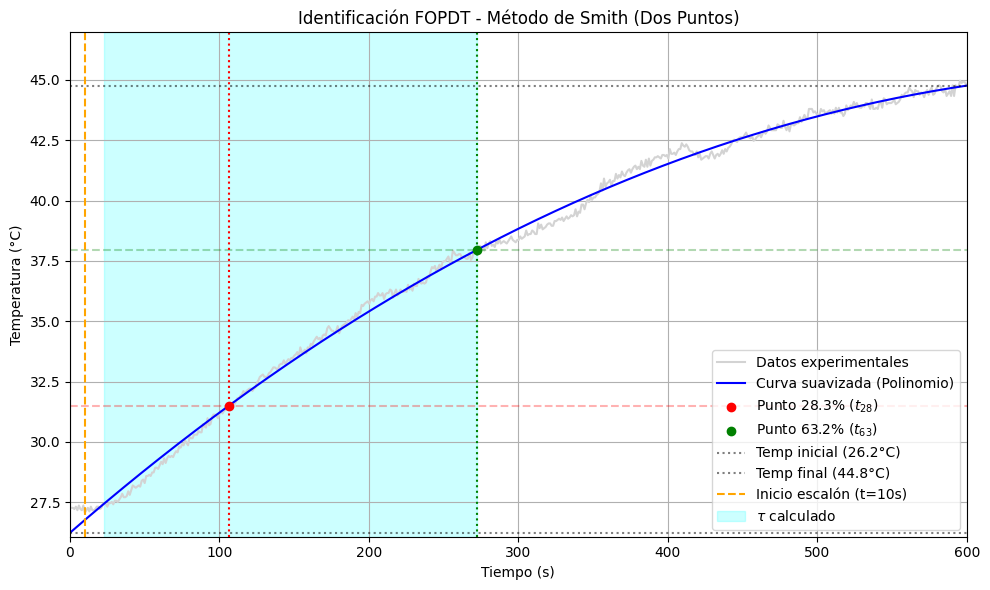

In [ ]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("data.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp1 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 0 y 600 s
# -----------------------------
mask = (t >= 0) & (t <= 600)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado original)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(0, 600, 600)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Cálculos del Método de Smith (Dos puntos)
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]
delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado en %
t_escalon = 10.0  # El escalón de potencia se aplicó en el segundo 10

# Calculamos las temperaturas objetivo (28.3% y 63.2% del cambio total)
y_28 = y0 + (0.283 * delta_y)
y_63 = y0 + (0.632 * delta_y)

# Buscamos en qué índice (y por tanto, qué tiempo) se alcanzan esas temperaturas
indice_28 = np.where(temp_suave >= y_28)[0][0]
t_28 = t_suave[indice_28]

indice_63 = np.where(temp_suave >= y_63)[0][0]
t_63 = t_suave[indice_63]

# -----------------------------
# 5. Calcular Parámetros FOPDT (Fórmulas de Smith)
# -----------------------------
# Calculamos tau según la fórmula de Smith
tau = 1.5 * (t_63 - t_28)

# Calculamos el cruce con la base (tiempo muerto absoluto)
t_m_absoluto = t_63 - tau

# Restamos el tiempo del escalón para tener el tiempo muerto real
theta = t_m_absoluto

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.3f}")
print(f"Temperatura al 28.3% (y_28): {y_28:.2f} °C en t={t_28:.2f} s")
print(f"Temperatura al 63.2% (y_63): {y_63:.2f} °C en t={t_63:.2f} s")
print(f"theta (tiempo muerto real): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 6. Graficar
# -----------------------------
plt.figure(figsize=(10, 6))

# Curvas principales
plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada (Polinomio)", color="blue")

# Puntos clave de Smith
plt.scatter(t_28, y_28, color="red", zorder=5, label="Punto 28.3% ($t_{28}$)")
plt.scatter(t_63, y_63, color="green", zorder=5, label="Punto 63.2% ($t_{63}$)")

# Líneas horizontales de referencia
plt.axhline(y0, color="black", linestyle=":", alpha=0.5, label=f"Temp inicial ({y0:.1f}°C)")
plt.axhline(yf, color="black", linestyle=":", alpha=0.5, label=f"Temp final ({yf:.1f}°C)")
plt.axhline(y_28, color="red", linestyle="--", alpha=0.3)
plt.axhline(y_63, color="green", linestyle="--", alpha=0.3)

# Líneas verticales marcando los tiempos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (t=10s)")
plt.axvline(t_28, linestyle=":", color="red")
plt.axvline(t_63, linestyle=":", color="green")

# Sombrear las zonas calculadas (Opcional, para visualizar tau)
plt.axvspan(t_m_absoluto, t_m_absoluto + tau, color='cyan', alpha=0.2, label=r'$\tau$ calculado')

# Configuraciones del gráfico
plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Identificación FOPDT - Método de Smith (Dos Puntos)")
plt.legend(loc="lower right")
plt.grid(True)

# Ajuste de ejes para mejor visualización
plt.xlim(0, 600)
plt.ylim(min(temp)-1, max(temp)+2)

plt.tight_layout()
plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.93
$$

**Constante de tiempo:**

$$
T_s = 249.42 \; s
$$

**Tiempo muerto:**

$$
\theta = 23.04 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.93}{249.42\,s + 1}\,e^{-23.04\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

### Validación del modelo

RMSE del modelo: 0.6394682306750474


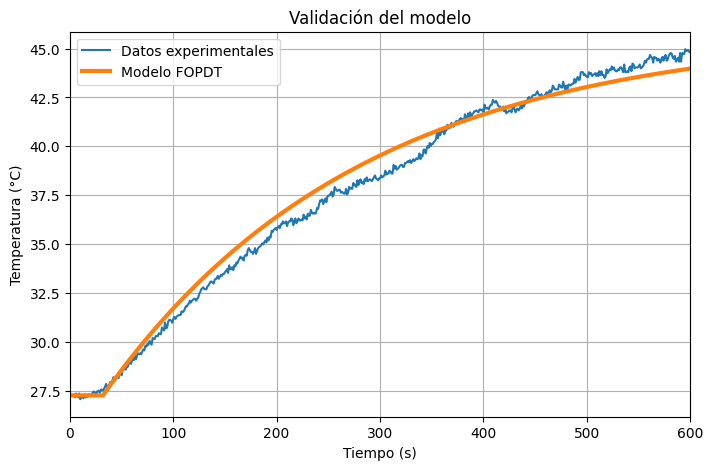

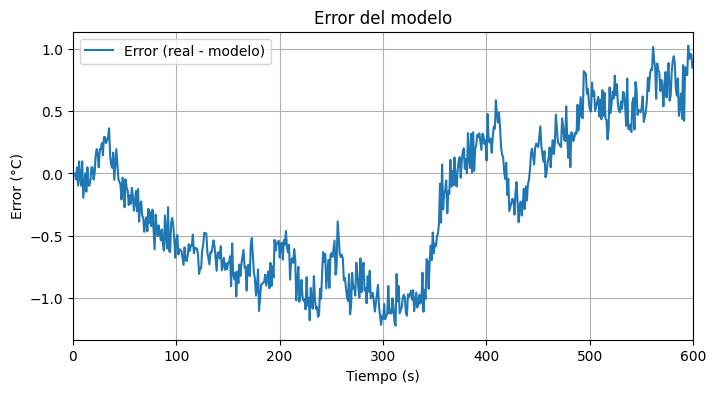

In [40]:
# parametros identificados
K = 0.93
tau = 249.42
theta = 23.04

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 10] = 20   # escalón aplicado en t = 10 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(0,600)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(0,600)

plt.show()

In [41]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.6957045118589131 %


## Heater 2 - SMITH

K (ganancia estática): 0.919
Temperatura al 28.3% (y_28): 32.90 °C en t=267.87 s
Temperatura al 63.2% (y_63): 39.32 °C en t=402.24 s
theta (tiempo muerto real): 10.69 s
tau (constante de tiempo): 201.55 s


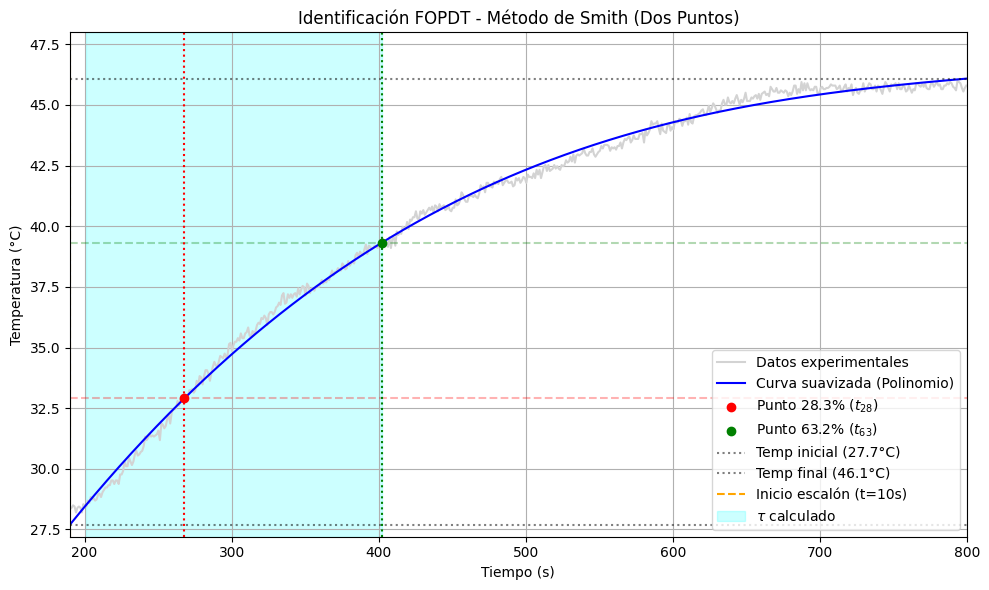

In [46]:
# -----------------------------
# 1. Leer archivo
# -----------------------------
data = pd.read_csv("data.txt", encoding="latin1")

t = data["Tiempo (s)"]
temp = data[" Temp2 (°C)"]

# -----------------------------
# 2. Filtrar datos entre 190 y 800 s
# -----------------------------
mask = (t >= 190) & (t <= 800)

t = t[mask].values
temp = temp[mask].values

# -----------------------------
# 3. Ajuste polinomial (suavizado original)
# -----------------------------
grado = 3

coef = np.polyfit(t, temp, grado)

polinomio = np.poly1d(coef)

t_suave = np.linspace(190, 800, 800)
temp_suave = polinomio(t_suave)

# -----------------------------
# 4. Cálculos del Método de Smith (Dos puntos)
# -----------------------------
y0 = temp_suave[0]
yf = temp_suave[-1]
delta_y = yf - y0
delta_u = 20   # tamaño del escalón aplicado en %
t_escalon = 190.0  # El escalón de potencia se aplicó en el segundo 10

# Calculamos las temperaturas objetivo (28.3% y 63.2% del cambio total)
y_28 = y0 + (0.283 * delta_y)
y_63 = y0 + (0.632 * delta_y)

# Buscamos en qué índice (y por tanto, qué tiempo) se alcanzan esas temperaturas
indice_28 = np.where(temp_suave >= y_28)[0][0]
t_28 = t_suave[indice_28]

indice_63 = np.where(temp_suave >= y_63)[0][0]
t_63 = t_suave[indice_63]

# -----------------------------
# 5. Calcular Parámetros FOPDT (Fórmulas de Smith)
# -----------------------------
# Calculamos tau según la fórmula de Smith
tau = 1.5 * (t_63 - t_28)

# Calculamos el cruce con la base (tiempo muerto absoluto)
t_m_absoluto = t_63 - tau

# Restamos el tiempo del escalón para tener el tiempo muerto real
theta = t_m_absoluto - t_escalon

K = delta_y / delta_u

print(f"K (ganancia estática): {K:.3f}")
print(f"Temperatura al 28.3% (y_28): {y_28:.2f} °C en t={t_28:.2f} s")
print(f"Temperatura al 63.2% (y_63): {y_63:.2f} °C en t={t_63:.2f} s")
print(f"theta (tiempo muerto real): {theta:.2f} s")
print(f"tau (constante de tiempo): {tau:.2f} s")

# -----------------------------
# 6. Graficar
# -----------------------------
plt.figure(figsize=(10, 6))

# Curvas principales
plt.plot(t, temp, label="Datos experimentales", color="lightgray")
plt.plot(t_suave, temp_suave, label="Curva suavizada (Polinomio)", color="blue")

# Puntos clave de Smith
plt.scatter(t_28, y_28, color="red", zorder=5, label="Punto 28.3% ($t_{28}$)")
plt.scatter(t_63, y_63, color="green", zorder=5, label="Punto 63.2% ($t_{63}$)")

# Líneas horizontales de referencia
plt.axhline(y0, color="black", linestyle=":", alpha=0.5, label=f"Temp inicial ({y0:.1f}°C)")
plt.axhline(yf, color="black", linestyle=":", alpha=0.5, label=f"Temp final ({yf:.1f}°C)")
plt.axhline(y_28, color="red", linestyle="--", alpha=0.3)
plt.axhline(y_63, color="green", linestyle="--", alpha=0.3)

# Líneas verticales marcando los tiempos
plt.axvline(t_escalon, linestyle="--", color="orange", label="Inicio escalón (t=10s)")
plt.axvline(t_28, linestyle=":", color="red")
plt.axvline(t_63, linestyle=":", color="green")

# Sombrear las zonas calculadas (Opcional, para visualizar tau)
plt.axvspan(t_m_absoluto, t_m_absoluto + tau, color='cyan', alpha=0.2, label=r'$\tau$ calculado')

# Configuraciones del gráfico
plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Identificación FOPDT - Método de Smith (Dos Puntos)")
plt.legend(loc="lower right")
plt.grid(True)

# Ajuste de ejes para mejor visualización
plt.xlim(190, 800)
plt.ylim(min(temp)-1, max(temp)+2)

plt.tight_layout()
plt.show()

### Modelo del proceso identificado

A partir del método de la tangente de Ziegler–Nichols, se obtuvieron los siguientes parámetros del proceso:

**Ganancia estática:**

$$
K = 0.92
$$

**Constante de tiempo:**

$$
T_s = 201.55 \; s
$$

**Tiempo muerto:**

$$
\theta = 10.69 \; s
$$

---

### Función de transferencia del proceso

El modelo aproximado del proceso de **primer orden con tiempo muerto (FOPDT)** es:

$$
G(s)=\frac{K}{T_s s + 1}e^{-\theta s}
$$

Sustituyendo los parámetros identificados:

$$
G(s)=\frac{0.92}{201.55\,s + 1}\,e^{-10.69\,s}
$$

donde:

- $K$ es la **ganancia estática del proceso**
- $T_s$ es la **constante de tiempo del sistema**
- $\theta$ es el **tiempo muerto del proceso**

### Validación del modelo

RMSE del modelo: 0.5458343603411918


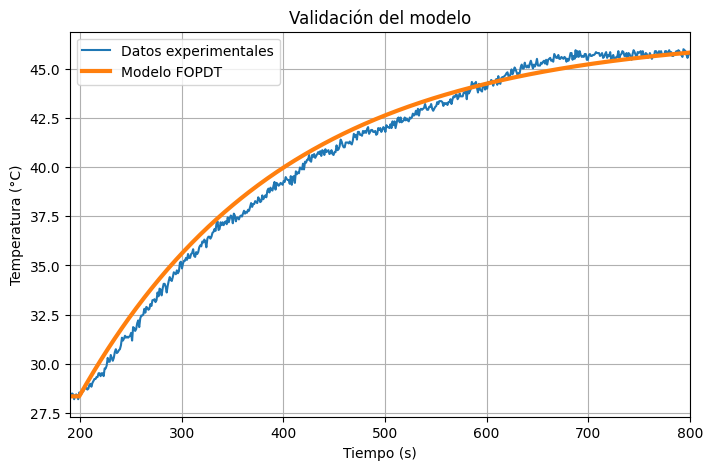

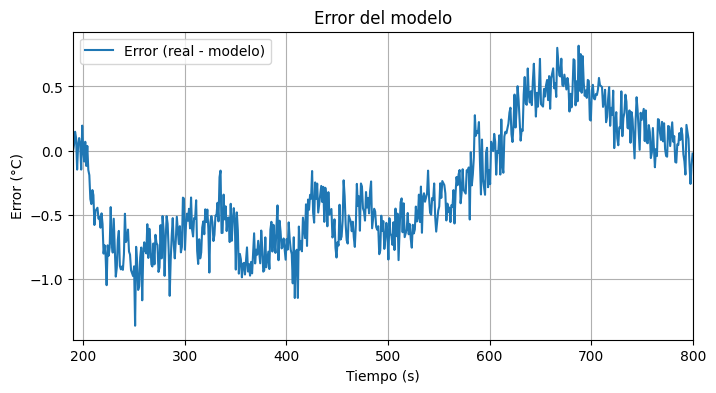

In [47]:
# parametros identificados
K = 0.92
tau = 201.55
theta = 10.69

# datos experimentales
t = t
y_real = temp

dt = t[1] - t[0]

# condiciones iniciales
y0 = y_real[0]
u0 = 0

# entrada del experimento
u = np.zeros_like(t)
u[t >= 190] = 20   # escalón aplicado en t = 190 s

delay_steps = int(theta/dt)

u_delay = np.zeros_like(u)

if delay_steps == 0:
    u_delay = u.copy()
else:
    u_delay[delay_steps:] = u[:-delay_steps]

# simulacion del modelo
y_model = np.zeros_like(t)
y_model[0] = y0

for i in range(1,len(t)):
    
    dy = (-(y_model[i-1] - y0) + K*(u_delay[i] - u0)) / tau
    
    y_model[i] = y_model[i-1] + dy*dt

# -----------------------------
# Calcular error
# -----------------------------
error = y_real - y_model

# RMSE
rmse = np.sqrt(np.mean(error**2))

print("RMSE del modelo:", rmse)

# -----------------------------
# Graficar comparacion
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t,y_real,label="Datos experimentales")
plt.plot(t,y_model,label="Modelo FOPDT",linewidth=3)

plt.xlabel("Tiempo (s)")
plt.ylabel("Temperatura (°C)")
plt.title("Validación del modelo")

plt.legend()
plt.grid()

plt.xlim(190, 800)

plt.show()


# -----------------------------
# Graficar error
# -----------------------------
plt.figure(figsize=(8,4))

plt.plot(t,error,label="Error (real - modelo)")

plt.xlabel("Tiempo (s)")
plt.ylabel("Error (°C)")
plt.title("Error del modelo")

plt.grid()
plt.legend()

plt.xlim(190, 800)

plt.show()

In [48]:
error_percent = rmse / np.mean(y_real) * 100

print("Error porcentual:", error_percent,"%")

Error porcentual: 1.3502560867785849 %


# Tabla comparativa 2 métodos


| Método | θ (s) | τ (s) | K | RMSE | Error (%) |
|:---|---:|---:|---:|---:|---:|
| **Tangente - Q1** | 9.03 | 182.13 | 0.53 | 0.71 | 1.86 |
| **Tangente - Q2** | 10.03 | 249.48 | 0.77 | 0.63 | 1.73 |
| **Smith - Q1** | 11.02 | 129.22 | 0.53 | 0.68 | 1.80 |
| **Smith - Q2** | 8.51 | 196.83 | 0.77 | 0.56 | 1.55 |
| **Tangente (Perturbación) - Q1** | 5.03 | 355.20 | 0.93 | 1.5 | 4.12 |
| **Tangente (Perturbación) - Q2** | 5.01 | 282.64 | 0.92 | 1.49 | 3.70 |
| **Smith (Perturbación) - Q2** | 23.04 | 249.42 | 0.93 | 0.63 | 1.69 |
| **Smith (Perturbación) - Q2** | 10.69 | 201.55 | 0.92 | 0.54 | 1.35 |


**Leyenda:**
- **θ (s)**: Tiempo muerto (dead time)
- **τ (s)**: Constante de tiempo (time constant)
- **K**: Ganancia estática del proceso
- **RMSE**: Raíz del error cuadrático medio
- **Error (%)**: Porcentaje de error relativo
- **Q1**: Heater 1 | **Q2**: Heater 2